# GWPopulation Tutorial

In [112]:
import gwpopulation as gwpop
import numpy as np
import matplotlib.pyplot as plt

In [113]:
plt.rcParams.update({
        'axes.grid': False,
        'axes.labelsize': 12,
        'axes.linewidth': 0.8,
        'axes.titlesize': 12,
        'font.size': 16,
        'legend.fontsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'font.family': 'serif',
        'font.sans-serif': ['Bitstream Vera Sans'],
        'font.serif': ['Times New Roman'],
        'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts}',
        'text.usetex': True,
        'patch.force_edgecolor': True,
        'figure.dpi': 100,
        'savefig.dpi': 100,
    }
)

## Overview of Hierarchical Inference
With an ever growing catalog of GW events, can we make statements about the underlying distribution properties of compact objects in the universe. Fundamentally, we want to compute the following:

\begin{align}
p(\vec{\Lambda} \vert \{\vec{d}_i\}) = \frac{\mathcal{L}(\{\vec{d}_i\} \vert \vec{\Lambda}) \pi (\vec{\Lambda})}{Z(\{\vec{d}_i\})}
\end{align}

where

- $\vec{\Lambda} = (\alpha_1, m_\mathrm{break}, \mu_1^\mathrm{peak}, \cdots , \mu_\chi, \sigma_\chi, \cdots, \kappa, \cdots, \delta \psi_\mathrm{nGR})$ are a set of hyperparameters that govern the shape of the mass, spin, etc. distributions.
- $\{\vec{d}_i\} = \{\vec{d}_1, \vec{d}_2, \cdots, \vec{d}_n\}$ is the set of data for $n$ events.

Typically, uniform priors on $\vec{\Lambda}$ are chosen. The main task is then to construct an appropriate expression for the likelihood, $\mathcal{L}(\{\vec{d_i}\} \vert \vec{\Lambda})$. This function tells us the probability of obtaining our current GW dataset given a set of hyperparameters. However, GW observations suffer from the Malmquist bias (louder/quieter signals are more/less likely to be detected), so we need to incorporate selection effects into the likelihood. From [Mandel et al. 2019](https://arxiv.org/abs/1809.02063), the likelihood is given by

\begin{align}
\mathcal{L}(\{\vec{d}_i\} \vert \vec{\Lambda}) \propto \frac{1}{\xi(\vec{\Lambda})^{N_\mathrm{obs}}} \prod_{i=1}^{N_\mathrm{obs}} \int \mathrm{d}\vec{\theta} \mathcal{L}(\vec{d}_i \vert \vec{\theta}) p_\mathrm{pop}(\vec{\theta} \vert \vec{\Lambda}).
\end{align}

Modelling the rate of observations as a Poisson process, i.e.

\begin{align}
    p(N_\mathrm{obs} \vert N_\mathrm{exp}) = \frac{(N_\mathrm{exp})^{N_\mathrm{obs}}}{N_\mathrm{obs}!} e^{-N_\mathrm{exp}}
\end{align}

where $N_\mathrm{exp}(\Lambda) = N \xi(\Lambda)$, the likelihood now becomes

\begin{align}
\mathcal{L}(\{\vec{d}_i\} \vert \vec{\Lambda}, N_\mathrm{exp}) = \mathcal{L}(\{\vec{d}_i\} \vert \vec{\Lambda}, N_\mathrm{obs})p(N_\mathrm{obs} \vert N_\mathrm{exp}) \propto N^{N_\mathrm{obs}} e^{-N_\mathrm{exp}(\Lambda)} \prod_{i=1}^{N_\mathrm{obs}} \int \mathrm{d}\vec{\theta} \mathcal{L}(\vec{d}_i \vert \vec{\theta}) p_\mathrm{pop}(\vec{\theta} \vert \vec{\Lambda}).
\end{align}

Now the problem reduces to calculating two parts, the selection function $\xi(\Lambda)$ and the integrals over the individual event likelihoods using importance sampling.

## Estimating the Likelihood Integrals

The goal of population anaylsis is to infer the hyperparameters of the underlying distributions from the data of individual GW detections. For individual events, we have

\begin{align}
p(\vec{\theta} \vert \vec{d}) = \frac{\mathcal{L}(\vec{d} \vert \vec{\theta}) \pi(\vec{\theta})}{Z(\vec{d})}
\end{align}

so our likelihood can be expressed as

\begin{align}
\mathcal{L}(\vec{d} \vert \vec{\theta}) = \frac{p(\vec{\theta} \vert \vec{d}) Z(\vec{d})}{\pi(\vec{\theta})}
\end{align}

Now, we can identify our integral as an expectation value under $p(\vec{\theta}_i \vert \vec{d}_i)$, i.e.

\begin{align}
\int \mathrm{d}\vec{\theta}_i \mathcal{L}(\vec{d}_i \vert \vec{\theta}_i) p_\mathrm{pop}(\vec{\theta}_i \vert \vec{\Lambda}) = \int \mathrm{d}\vec{\theta}_i \frac{p_\mathrm{pop}(\vec{\theta}_i \vert \vec{\Lambda}) Z(\vec{d}_i)}{\pi(\vec{\theta}_i)} p(\vec{\theta}_i \vert \vec{d}_i) = E_p\Bigg[ \frac{p_\mathrm{pop}(\vec{\theta}_i \vert \vec{\Lambda}) Z(\vec{d}_i)}{\pi(\vec{\theta}_i)} \Bigg]
\end{align}

which can be approximated with a Monte Carlo sum

\begin{align}
E_p\Bigg[ \frac{p_\mathrm{pop}(\vec{\theta}_i \vert \vec{\Lambda}) Z(\vec{d}_i)}{\pi(\vec{\theta}_i)} \Bigg] \approx \frac{1}{S_i} \sum_{j=1}^{S_i} \frac{p_\mathrm{pop} (\vec{\theta}^j_i \vert \Lambda) Z(\vec{d}_i)}{\pi(\vec{\theta}^j_i)}
\end{align}

where it is implied that the samples are taking from the distribution $p(\vec{\theta}_i \vert \vec{d}_i)$.

## Estimating the Selection Function


The selection function tells us the fraction of events that are detectable for a given population model. Typically, specific SNR and/or IFAR values are chosen as the detection threshold, $d_\mathrm{t}$. Only events that fall above this threshold are considered detected. For a given set of source parameters, the probability of detection is given by

\begin{align}
    p_\mathrm{det}(\vec{\theta}) = \int_{\vec{d} > d_t} \mathrm{d} \vec{d} p(\vec{d} \vert \vec{\theta}) 
\end{align}

where we marginalise over all possible data realisations for $\vec{\theta}$ as dictated by our likelihood function. From [Mandel et al. 2019](https://arxiv.org/abs/1809.02063), the selection function is given by the convolution of $p_\mathrm{det}(\vec{\theta})$ and $p_\mathrm{pop}(\vec{\theta} \vert \vec{\Lambda})$

\begin{align}
    \xi(\vec{\Lambda}) = \int d \vec{\theta} p_\mathrm{det}(\vec{\theta}) p_\mathrm{pop}(\vec{\theta} \vert \vec{\Lambda})
\end{align}

Let's see how this works for some toy models. We'll (boldly) reduce our parameter space down to the primary mass, $m_1$, for simplicity and consider the following double power law population model:

\begin{equation}
p_\mathrm{pop}(m_1 \mid \alpha_1, \alpha_2, m_{\min}, m_{\max}, \delta)
\propto
\begin{cases}
m_1^{-\alpha_1},
& m_{\min} \le m_1 < m_{\min} + \delta (m_{\max} - m_{\min}) \\[6pt]
m_1^{-\alpha_2},
& m_{\min} + \delta (m_{\max} - m_{\min})
\le m_1 < m_{\max}
\end{cases}
\end{equation}

with the two cases considered being $p_\mathrm{pop}(m_1 \mid \vec{\Lambda}_1) = p_\mathrm{pop}(m_1 \mid 1.1, 4.0, 5, 50, 0.5)$ and $p_\mathrm{pop}(m_1 \mid \vec{\Lambda}_2) = p_\mathrm{pop}(m_1 \mid 0.1, 1.2, 5, 90, 0.8)$. We will also assume that only sources with $m_1 > 20 M_\odot$ can be detected, i.e. $p_\mathrm{det}(m_1) \sim H(m_1 - 20)$.

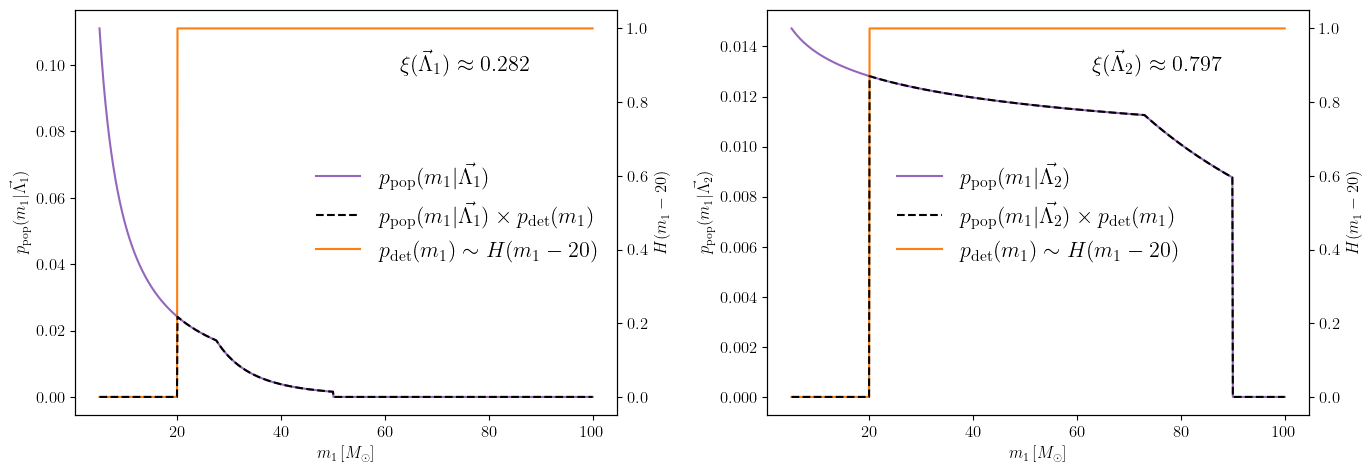

In [123]:
m = np.linspace(5, 100, 1000)
pm1 = gwpop.models.mass.double_power_law_primary_mass(m, alpha_1=1.1, alpha_2=4.0, mmin=5, mmax=50, break_fraction=0.5)
pm2 = gwpop.models.mass.double_power_law_primary_mass(m, alpha_1=0.1, alpha_2=1.2, mmin=5, mmax=90, break_fraction=0.8)
heaviside = np.heaviside(m - 20, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax_pop in axes:

    ax_det = ax_pop.twinx()

    if ax_pop == axes[0]:
        pm = pm1
        ax_pop.set_ylabel(r'$p_\mathrm{pop}(m_1 \vert \vec{\Lambda_1})$')
    else:
        pm = pm2
        ax_pop.set_ylabel(r'$p_\mathrm{pop}(m_1 \vert \vec{\Lambda_2})$')

    ax_det.set_ylabel(r'$H(m_1 - 20)$')
    ax_pop.set_xlabel(r'$m_1\,[M_\odot]$')

    if ax_pop == axes[0]:
    
        ax_pop.plot(
            m, pm,
            label=r'$p_\mathrm{pop}(m_1 \vert \vec{\Lambda_1})$',
            c='tab:purple'
        )
    else:
        ax_pop.plot(
            m, pm,
            label=r'$p_\mathrm{pop}(m_1 \vert \vec{\Lambda_2})$',
            c='tab:purple'
        )
    
    
    ax_det.plot(
        m, heaviside,
        label=r'$p_\mathrm{det}(m_1) \sim H(m_1 - 20)$',
        c='tab:orange'
    )
    ax_det.set_ylim(-0.05, 1.05)

    # Ensure population axis is on top
    ax_pop.set_zorder(ax_det.get_zorder() + 1)
    ax_pop.patch.set_visible(False)

    if ax_pop == axes[0]:
        ax_pop.plot(
            m, pm * heaviside,
            label=r'$p_\mathrm{pop}(m_1 \vert \vec{\Lambda_1}) \times p_\mathrm{det}(m_1)$',
            c='k',
            linestyle='--',
            zorder=2
        )
    else:
        ax_pop.plot(
            m, pm * heaviside,
            label=r'$p_\mathrm{pop}(m_1 \vert \vec{\Lambda_2}) \times p_\mathrm{det}(m_1)$',
            c='k',
            linestyle='--',
            zorder=2
        )

    # --- Combined legend (per subplot) ---
    lines1, labels1 = ax_pop.get_legend_handles_labels()
    lines2, labels2 = ax_det.get_legend_handles_labels()
    if ax_pop == axes[0]:
        ax_pop.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc='center right',
            frameon=False
        )
    else:
        ax_pop.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc='center',
            frameon=False
        )

# Evaluate xi
dx = m[1] - m[0]
xi1_riemann = np.sum(pm1 * heaviside) * dx
xi2_riemann = np.sum(pm2 * heaviside) * dx

axes[0].text(
    0.6, 0.9,
    rf'$\xi(\vec{{\Lambda}}_1)\approx {xi1_riemann:.3f}$',
    transform=axes[0].transAxes,
    va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)
axes[1].text(
    0.6, 0.9,
    rf'$\xi(\vec{{\Lambda}}_2)\approx {xi2_riemann:.3f}$',
    transform=axes[1].transAxes,
    va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

plt.tight_layout()
plt.show()

Clearly, there is a much larger contribution to the integral $\xi(\vec{\Lambda}_2)$ than $\xi(\vec{\Lambda}_1)$, as there is greater probability of sampling sources with $m_1 > 20 M_\odot$ from $p_\mathrm{pop}(m_1 \mid \vec{\Lambda}_2)$. Computing the integrals, we find $\xi(\vec{\Lambda}_1) \approx 0.282$ and $\xi(\vec{\Lambda}_2) \approx 0.797$.  Without selection effects, $\vec{\Lambda}_1$ would be punished for being dominated by low masses and would therefore have reduced posterior support. However, $\xi$ effectively re-weights this sample, and therefore naturally accounts for the Malmquist bias.

In practise, these integrals are analytically intractable and numerically expensive to compute. Therefore, we resort once again to Monte Carlo simulations and importance sampling.